**Daniel Lee**  
Thomas Jefferson High School for Science and Technology


# Modeling Asthma Exacerbation Risk Using Environmental Data and Differential Equations

This project develops a mathematical framework for studying how changing environmental conditions may influence simulated asthma-related inflammation over time.

Daily PM2.5, ozone, temperature, and humidity measurements from the Fairfax County / Dulles, Virginia area during 2024 are normalized and combined into an environmental exposure index.

That exposure index is used as the forcing input to an ordinary differential equation modeling the balance between environmentally driven increases in inflammation and medication/natural recovery.

## Research Question

**How do the timing, magnitude, and duration of combined environmental exposure affect simulated asthma-related inflammation over time?**

## Important Interpretation

The environmental measurements used in this project are real data. However, the inflammation state and risk index are mathematical simulations and are not clinical measurements or medically validated predictions.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Model Parameters

The inflammation model is

$$
\frac{dI}{dt}
=
\alpha E(t)(1-I)
-
[\beta M+\gamma]I
$$

where:

- $I(t)$: normalized simulated inflammation
- $E(t)$: normalized environmental exposure
- $\alpha$: environmental response parameter
- $\beta$: medication effectiveness parameter
- $M$: normalized medication level
- $\gamma$: natural recovery parameter

All parameter values used here are preliminary modeling assumptions and have not been clinically calibrated.

In [ ]:
alpha = 0.35
beta = 0.25
gamma = 0.10

medication_level = 0.20
initial_inflammation = 0.10

# Illustrative risk-index parameters
b0 = -3.0
b1 = 5.0
b2 = 1.0

baseline_vulnerability = 0.40

print("Model parameters loaded.")

Model parameters loaded.


In [ ]:
real_data = pd.read_csv(
    "fairfax_environmental_data_2024.csv",
    parse_dates=["Date"]
)

display(real_data.head())

print("Dataset shape:", real_data.shape)
print("\nMissing values:")
print(real_data.isna().sum())

,Date,PM25,Ozone,Temperature,Humidity
0,2024-01-01,9.7,0.020,3.9,77.0
1,2024-01-02,4.6,0.028,3.6,59.0
2,2024-01-03,7.5,0.022,3.1,58.0
3,2024-01-04,5.3,0.031,3.4,57.0
4,2024-01-05,7.1,0.028,-0.5,59.0


Dataset shape: (365, 5)

Missing values:
Date           0
PM25           0
Ozone          0
Temperature    0
Humidity       0
dtype: int64


In [ ]:
dates = real_data["Date"]

pm25 = real_data["PM25"].to_numpy()
ozone = real_data["Ozone"].to_numpy()
temperature = real_data["Temperature"].to_numpy()
humidity = real_data["Humidity"].to_numpy()

days = len(real_data)
t_data = np.arange(days)

print("Number of days:", days)

print("First five PM2.5 values:")
print(pm25[:5])

print("First five ozone values:")
print(ozone[:5])

print("First five temperature values:")
print(temperature[:5])

print("First five humidity values:")
print(humidity[:5])

Number of days: 365
First five PM2.5 values:
[9.7 4.6 7.5 5.3 7.1]
First five ozone values:
[0.02  0.028 0.022 0.031 0.028]
First five temperature values:
[ 3.9  3.6  3.1  3.4 -0.5]
First five humidity values:
[77. 59. 58. 57. 59.]


## Environmental Normalization

Because PM2.5, ozone, temperature, and humidity use different physical units, each variable is min-max normalized:

$$
x_{\mathrm{norm}}
=
\frac{x-x_{\min}}
{x_{\max}-x_{\min}}
$$

This maps each variable to the interval $[0,1]$.

The normalization is relative to the 2024 dataset and therefore does not represent a universal clinical exposure scale.

In [ ]:
def min_max_normalize(values):

    minimum = np.min(values)
    maximum = np.max(values)

    if maximum == minimum:
        raise ValueError(
            "Cannot normalize a variable with no variation."
        )

    return (
        (values - minimum)
        /
        (maximum - minimum)
    )


pm25_norm = min_max_normalize(pm25)
ozone_norm = min_max_normalize(ozone)
temperature_norm = min_max_normalize(temperature)
humidity_norm = min_max_normalize(humidity)


print(
    "PM2.5 range:",
    pm25_norm.min(),
    pm25_norm.max()
)

print(
    "Ozone range:",
    ozone_norm.min(),
    ozone_norm.max()
)

print(
    "Temperature range:",
    temperature_norm.min(),
    temperature_norm.max()
)

print(
    "Humidity range:",
    humidity_norm.min(),
    humidity_norm.max()
)

PM2.5 range: 0.0 1.0
Ozone range: 0.0 1.0
Temperature range: 0.0 1.0
Humidity range: 0.0 1.0


## Environmental Exposure Index

The normalized environmental measurements are combined into

$$
E(t)
=
0.40P(t)
+
0.30O(t)
+
0.15T(t)
+
0.15H(t)
$$

where $P(t)$, $O(t)$, $T(t)$, and $H(t)$ represent normalized PM2.5, ozone, temperature, and humidity.

The weights are preliminary modeling assumptions and are later tested through sensitivity analysis.

In [ ]:
w_pm25 = 0.40
w_ozone = 0.30
w_temperature = 0.15
w_humidity = 0.15

exposure = (
    w_pm25 * pm25_norm
    + w_ozone * ozone_norm
    + w_temperature * temperature_norm
    + w_humidity * humidity_norm
)

print(
    "Weight sum:",
    w_pm25
    + w_ozone
    + w_temperature
    + w_humidity
)

print("Minimum exposure:", exposure.min())
print("Maximum exposure:", exposure.max())
print("Mean exposure:", exposure.mean())

Weight sum: 1.0
Minimum exposure: 0.18011913109487676
Maximum exposure: 0.7987985632646845
Mean exposure: 0.4251856828657378


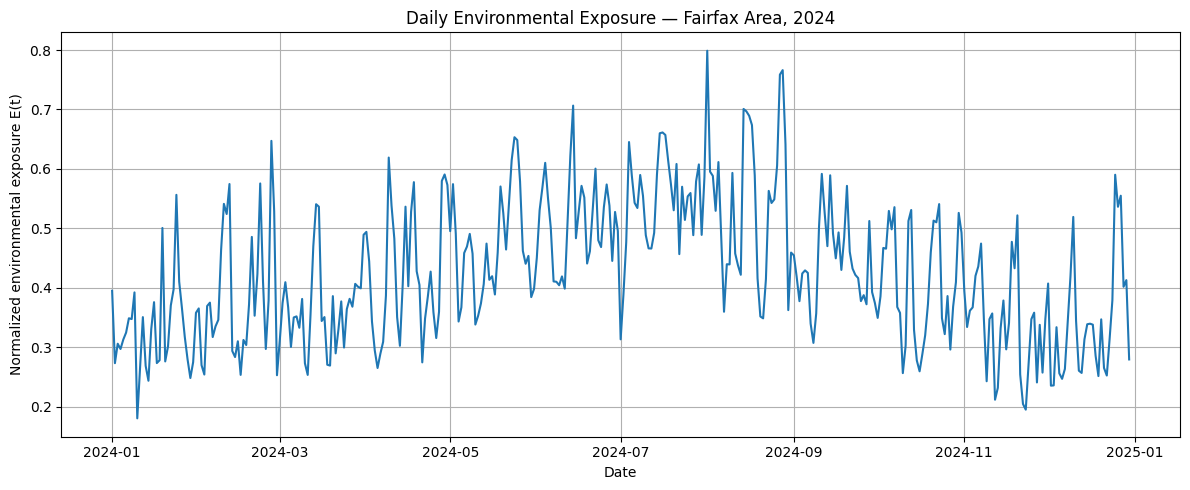

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    dates,
    exposure
)

plt.xlabel("Date")

plt.ylabel(
    "Normalized environmental exposure E(t)"
)

plt.title(
    "Daily Environmental Exposure — Fairfax Area, 2024"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "real_environmental_exposure_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
assert len(exposure) == len(dates)
assert len(exposure) == len(t_data)

assert not np.isnan(exposure).any()

assert np.all(
    exposure >= 0
)

assert np.all(
    exposure <= 1
)

assert np.isclose(
    w_pm25
    + w_ozone
    + w_temperature
    + w_humidity,
    1.0
)

print("Environmental-data checks passed.")

Environmental-data checks passed.


## Forward Inflammation Model

The inflammation state satisfies

$$
\frac{dI}{dt}
=
\alpha E(t)(1-I)
-
[\beta M+\gamma]I.
$$

The first term represents environmentally driven growth in inflammation. The factor $(1-I)$ prevents unlimited growth.

The second term represents medication effects and natural recovery.

Because the environmental data are available once per day, linear interpolation is used to estimate $E(t)$ between daily observations.

In [ ]:
def run_forward_model(
    exposure_values,
    alpha_value=0.35,
    beta_value=0.25,
    gamma_value=0.10,
    medication_value=0.20,
    initial_I=0.10,
    max_step=0.5,
    rtol=1e-6,
    atol=1e-8
):

    exposure_values = np.asarray(
        exposure_values,
        dtype=float
    )

    n_days = len(exposure_values)

    local_t = np.arange(n_days)

    def exposure_function(t):

        return np.interp(
            t,
            local_t,
            exposure_values
        )

    def model(t, y):

        I = y[0]

        E = exposure_function(t)

        dI_dt = (
            alpha_value
            * E
            * (1 - I)
            -
            (
                beta_value
                * medication_value
                + gamma_value
            )
            * I
        )

        return [dI_dt]

    solution = solve_ivp(
        model,
        (0, n_days - 1),
        [initial_I],
        t_eval=local_t,
        method="RK45",
        max_step=max_step,
        rtol=rtol,
        atol=atol
    )

    if not solution.success:

        raise RuntimeError(
            solution.message
        )

    return solution.y[0]


print("Forward model defined.")

Forward model defined.


In [ ]:
real_inflammation = run_forward_model(
    exposure_values=exposure,
    alpha_value=alpha,
    beta_value=beta,
    gamma_value=gamma,
    medication_value=medication_level,
    initial_I=initial_inflammation
)

print(
    "Minimum inflammation:",
    real_inflammation.min()
)

print(
    "Maximum inflammation:",
    real_inflammation.max()
)

print(
    "Mean inflammation:",
    real_inflammation.mean()
)

Minimum inflammation: 0.1
Maximum inflammation: 0.6031337812847415
Mean inflammation: 0.4886083300826838


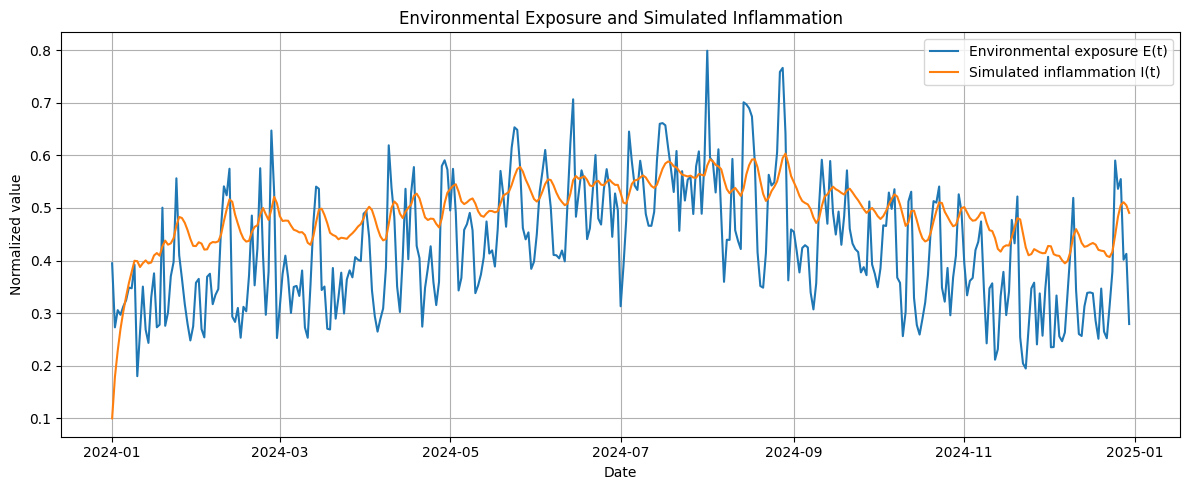

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    dates,
    exposure,
    label="Environmental exposure E(t)"
)

plt.plot(
    dates,
    real_inflammation,
    label="Simulated inflammation I(t)"
)

plt.xlabel("Date")
plt.ylabel("Normalized value")

plt.title(
    "Environmental Exposure and Simulated Inflammation"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "real_exposure_and_inflammation_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
baseline_results = pd.DataFrame({
    "Date": dates,
    "PM25": pm25,
    "Ozone": ozone,
    "Temperature": temperature,
    "Humidity": humidity,
    "Exposure": exposure,
    "SimulatedInflammation":
        real_inflammation
})

display(
    baseline_results.head()
)

print(
    "Baseline table shape:",
    baseline_results.shape
)

,Date,PM25,Ozone,Temperature,Humidity,Exposure,SimulatedInflammation
0,2024-01-01,9.7,0.020,3.9,77.0,0.394715,0.100000
1,2024-01-02,4.6,0.028,3.6,59.0,0.272948,0.178656
2,2024-01-03,7.5,0.022,3.1,58.0,0.305683,0.228634
3,2024-01-04,5.3,0.031,3.4,57.0,0.296815,0.270107
4,2024-01-05,7.1,0.028,-0.5,59.0,0.312757,0.303103


Baseline table shape: (365, 7)


## Broad Exposure Scenarios

Three year-long scenarios are compared:

- **Clean-air scenario:** $$0.5E(t)$$
- **Observed scenario:** $$E(t)$$
- **High-exposure scenario:** $$1.5E(t)$$, clipped to the interval $$[0,1]$$

These scenarios are mathematical stress tests and should not be interpreted as estimates of real-world intervention effects.

In [ ]:
clean_exposure = np.clip(
    exposure * 0.50,
    0,
    1
)

observed_exposure = exposure.copy()

high_exposure = np.clip(
    exposure * 1.50,
    0,
    1
)


I_clean = run_forward_model(
    clean_exposure
)

I_observed = real_inflammation

I_high = run_forward_model(
    high_exposure
)

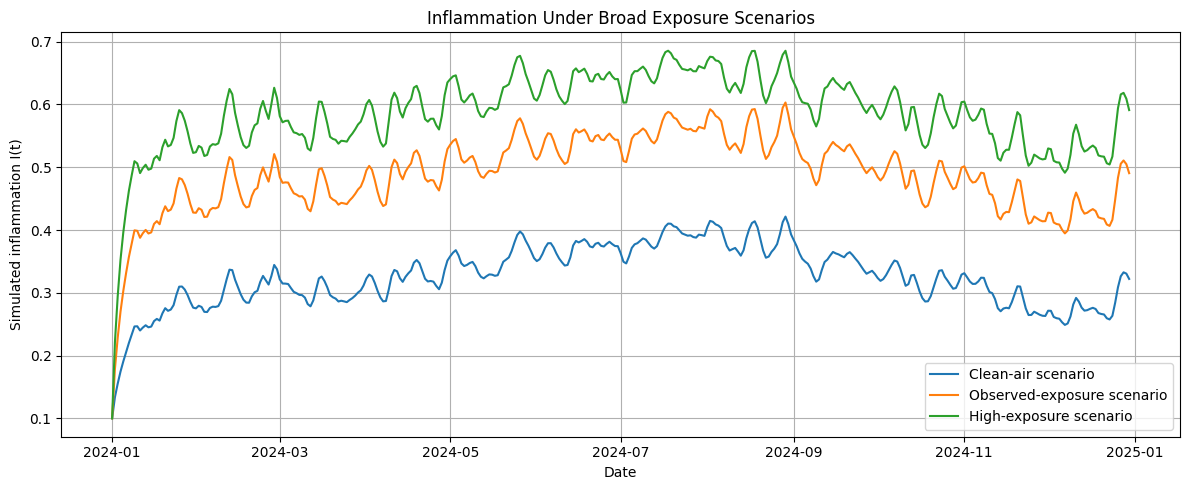

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    dates,
    I_clean,
    label="Clean-air scenario"
)

plt.plot(
    dates,
    I_observed,
    label="Observed-exposure scenario"
)

plt.plot(
    dates,
    I_high,
    label="High-exposure scenario"
)

plt.xlabel("Date")

plt.ylabel(
    "Simulated inflammation I(t)"
)

plt.title(
    "Inflammation Under Broad Exposure Scenarios"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "broad_exposure_scenarios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
observed_mean = np.mean(
    I_observed
)

scenario_table = pd.DataFrame({

    "Scenario": [
        "Clean air",
        "Observed exposure",
        "High exposure"
    ],

    "Mean inflammation": [
        np.mean(I_clean),
        np.mean(I_observed),
        np.mean(I_high)
    ],

    "Maximum inflammation": [
        np.max(I_clean),
        np.max(I_observed),
        np.max(I_high)
    ]
})

scenario_table[
    "Percent change in mean vs observed"
] = (
    100
    *
    (
        scenario_table[
            "Mean inflammation"
        ]
        - observed_mean
    )
    /
    observed_mean
)

display(scenario_table)

,Scenario,Mean inflammation,Maximum inflammation,Percent change in mean vs observed
0,Clean air,0.325725,0.421398,-33.336267
1,Observed exposure,0.488608,0.603134,0.000000
2,High exposure,0.586772,0.685650,20.090555


## Controlled Exposure Experiments

To study the research question more directly, controlled artificial exposure events are used.

The experiments vary:

1. exposure **magnitude** while keeping duration fixed;
2. exposure **duration** while keeping magnitude fixed;
3. exposure **timing** while keeping the added event approximately fixed.

The main response metrics include peak inflammation and excess inflammation area under the curve (AUC).

In [ ]:
def excess_auc(
    event_curve,
    baseline_curve
):

    difference = (
        event_curve
        - baseline_curve
    )

    return np.trapezoid(
        difference,
        t_data
    )

In [ ]:
pulse_baseline_exposure = 0.25

baseline_control_exposure = np.full(
    days,
    pulse_baseline_exposure
)

I_baseline_control = run_forward_model(
    baseline_control_exposure
)

print(
    "Pulse-control mean inflammation:",
    np.mean(I_baseline_control)
)

Pulse-control mean inflammation: 0.36494238977155485


In [ ]:
magnitude_event_start = 100
magnitude_event_duration = 7

magnitude_levels = [
    0.40,
    0.60,
    0.80
]

magnitude_curves = {}
magnitude_results = []

for level in magnitude_levels:

    test_exposure = np.full(
        days,
        pulse_baseline_exposure
    )

    test_exposure[
        magnitude_event_start:
        magnitude_event_start
        + magnitude_event_duration
    ] = level

    I_test = run_forward_model(
        test_exposure
    )

    magnitude_curves[
        level
    ] = I_test

    difference = (
        I_test
        - I_baseline_control
    )

    magnitude_results.append({

        "Exposure magnitude":
            level,

        "Peak inflammation":
            np.max(I_test),

        "Peak increase vs baseline":
            np.max(difference),

        "Excess inflammation AUC":
            np.trapezoid(
                difference,
                t_data
            )
    })


magnitude_table = pd.DataFrame(
    magnitude_results
)

display(magnitude_table)

,Exposure magnitude,Peak inflammation,Peak increase vs baseline,Excess inflammation AUC
0,0.4,0.465354,0.096933,0.876462
1,0.6,0.562554,0.194133,1.789414
2,0.8,0.633835,0.265414,2.490156


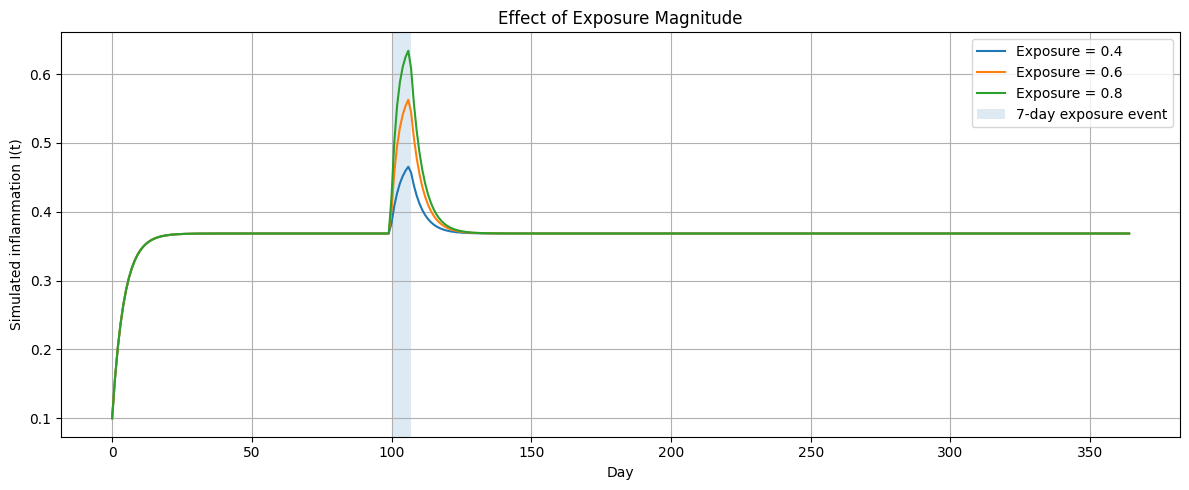

In [ ]:
plt.figure(figsize=(12, 5))

for level, curve in (
    magnitude_curves.items()
):

    plt.plot(
        t_data,
        curve,
        label=f"Exposure = {level}"
    )

plt.axvspan(
    magnitude_event_start,
    magnitude_event_start
    + magnitude_event_duration,
    alpha=0.15,
    label="7-day exposure event"
)

plt.xlabel("Day")

plt.ylabel(
    "Simulated inflammation I(t)"
)

plt.title(
    "Effect of Exposure Magnitude"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "magnitude_experiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
duration_event_start = 100

duration_exposure_level = 0.70

duration_values = [
    1,
    3,
    7,
    14
]

duration_curves = {}
duration_results = []

for duration in duration_values:

    test_exposure = np.full(
        days,
        pulse_baseline_exposure
    )

    test_exposure[
        duration_event_start:
        duration_event_start
        + duration
    ] = duration_exposure_level

    I_test = run_forward_model(
        test_exposure
    )

    duration_curves[
        duration
    ] = I_test

    difference = (
        I_test
        - I_baseline_control
    )

    duration_results.append({

        "Duration (days)":
            duration,

        "Peak inflammation":
            np.max(I_test),

        "Peak increase vs baseline":
            np.max(difference),

        "Excess inflammation AUC":
            np.trapezoid(
                difference,
                t_data
            )
    })


duration_table = pd.DataFrame(
    duration_results
)

display(duration_table)

,Duration (days),Peak inflammation,Peak increase vs baseline,Excess inflammation AUC
0,1,0.441657,0.073236,0.390779
1,3,0.526069,0.157647,1.051145
2,7,0.600854,0.232433,2.162084
3,14,0.619026,0.250605,3.949983


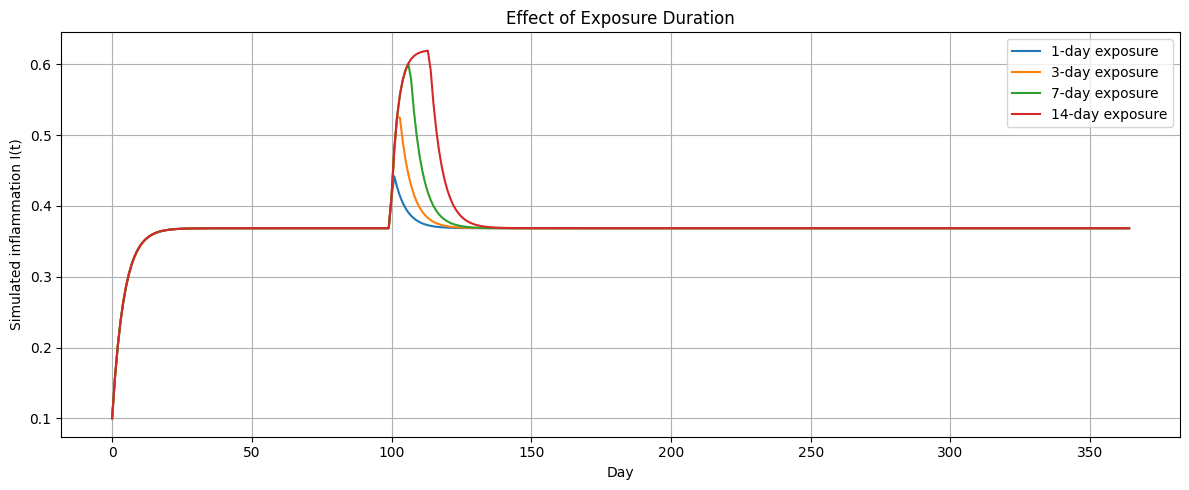

In [ ]:
plt.figure(figsize=(12, 5))

for duration, curve in (
    duration_curves.items()
):

    plt.plot(
        t_data,
        curve,
        label=f"{duration}-day exposure"
    )

plt.xlabel("Day")

plt.ylabel(
    "Simulated inflammation I(t)"
)

plt.title(
    "Effect of Exposure Duration"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "duration_experiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Exposure Timing Experiment

The magnitude and duration experiments use a constant background exposure. The timing experiment instead modifies the real 2024 environmental exposure data.

A 7-day exposure increase of 0.20 is introduced at three different times of the year.

This experiment asks whether the effect of an added exposure event depends on the environmental conditions already present when that event occurs.

In [ ]:
timing_event_starts = [
    60,
    180,
    300
]

timing_event_duration = 7
timing_exposure_increase = 0.20

timing_curves = {}
timing_results = []

for start in timing_event_starts:

    modified_exposure = exposure.copy()

    modified_exposure[
        start:
        start + timing_event_duration
    ] = np.clip(

        modified_exposure[
            start:
            start + timing_event_duration
        ]
        + timing_exposure_increase,

        0,
        1
    )

    I_test = run_forward_model(
        modified_exposure
    )

    timing_curves[start] = I_test

    difference = (
        I_test
        - real_inflammation
    )

    timing_results.append({

        "Event start day":
            start,

        "Event date":
            dates.iloc[start],

        "Background exposure":
            np.mean(
                exposure[
                    start:
                    start + timing_event_duration
                ]
            ),

        "Maximum added inflammation":
            np.max(difference),

        "Added inflammation AUC":
            np.trapezoid(
                difference,
                t_data
            )
    })


timing_table = pd.DataFrame(
    timing_results
)

display(timing_table)

,Event start day,Event date,Background exposure,Maximum added inflammation,Added inflammation AUC
0,60,2024-03-01,0.351934,0.097496,0.831313
1,180,2024-06-29,0.490670,0.076370,0.616093
2,300,2024-10-27,0.402851,0.088329,0.767972


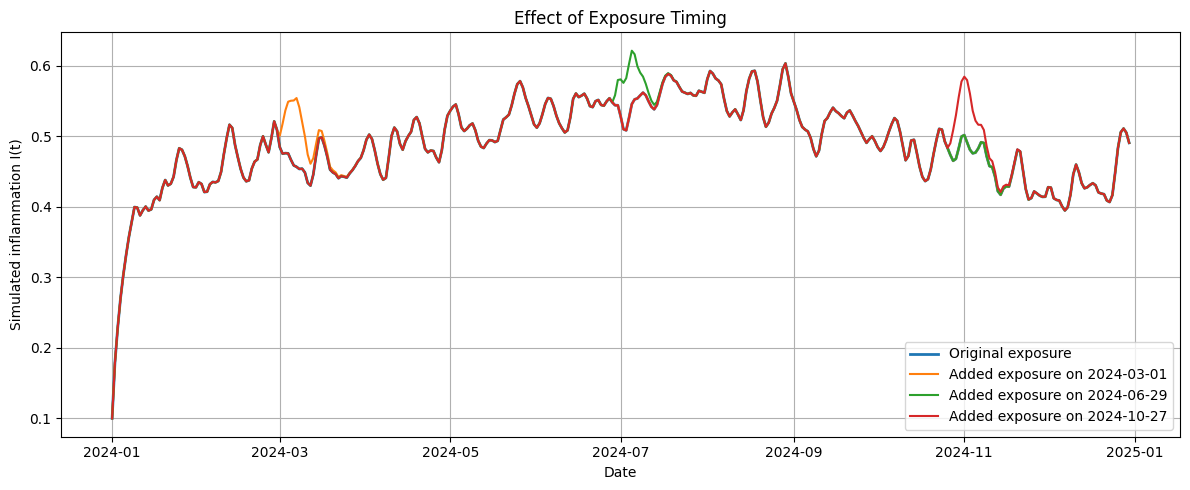

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    dates,
    real_inflammation,
    linewidth=2,
    label="Original exposure"
)

for start, curve in timing_curves.items():

    plt.plot(
        dates,
        curve,
        label=(
            "Added exposure on "
            f"{dates.iloc[start].date()}"
        )
    )

plt.xlabel("Date")

plt.ylabel(
    "Simulated inflammation I(t)"
)

plt.title(
    "Effect of Exposure Timing"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "timing_experiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model-Implied Exposure–Inflammation Lag

Because the differential equation contains accumulation and recovery, simulated inflammation does not necessarily track daily environmental exposure instantaneously.

To examine the temporal response of the model, correlations are calculated between environmental exposure and simulated inflammation at lags from 0 to 14 days.

This represents a **model-implied lag**, not an experimentally measured biological delay.

In [ ]:
max_lag = 14

lag_results = []

for lag in range(
    max_lag + 1
):

    if lag == 0:

        x = exposure
        y = real_inflammation

    else:

        x = exposure[:-lag]

        y = real_inflammation[
            lag:
        ]

    correlation = np.corrcoef(
        x,
        y
    )[0, 1]

    lag_results.append({

        "Lag (days)":
            lag,

        "Correlation":
            correlation
    })


lag_table = pd.DataFrame(
    lag_results
)

display(lag_table)

,Lag (days),Correlation
0,0,0.646780
1,1,0.770847
2,2,0.780502
3,3,0.727956
4,4,0.663341
5,5,0.603005
6,6,0.549808
7,7,0.509117
8,8,0.501309
9,9,0.512340


In [ ]:
best_lag_row = lag_table.loc[
    lag_table[
        "Correlation"
    ].idxmax()
]

best_lag = int(
    best_lag_row[
        "Lag (days)"
    ]
)

best_lag_correlation = (
    best_lag_row[
        "Correlation"
    ]
)

print(
    "Strongest model-implied lag:",
    best_lag,
    "days"
)

print(
    "Correlation:",
    best_lag_correlation
)

Strongest model-implied lag: 2 days
Correlation: 0.780501754174577


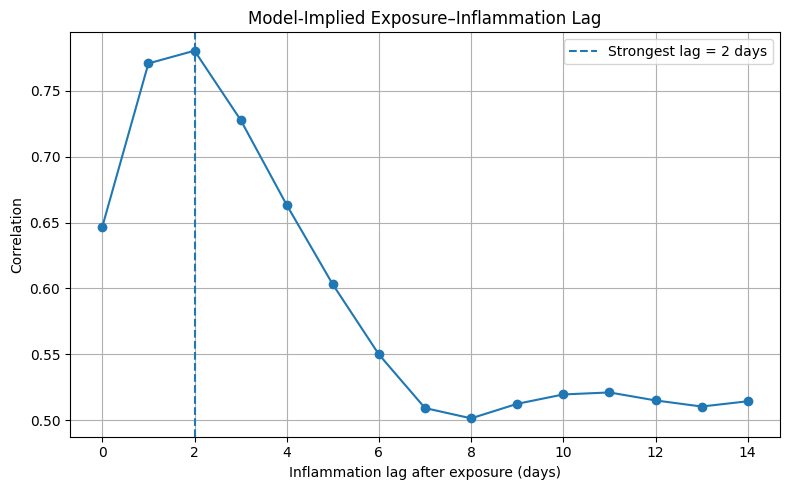

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lag_table["Lag (days)"],
    lag_table["Correlation"],
    marker="o"
)

plt.axvline(
    best_lag,
    linestyle="--",
    label=f"Strongest lag = {best_lag} days"
)

plt.xlabel(
    "Inflammation lag after exposure (days)"
)

plt.ylabel("Correlation")

plt.title(
    "Model-Implied Exposure–Inflammation Lag"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "lag_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Parameter Sensitivity Analysis

A one-at-a-time sensitivity analysis is used to examine how strongly the simulated inflammation trajectory depends on the assumed model parameters.

Each parameter is decreased by 20% and increased by 20% while all other parameters remain fixed.

The analysis evaluates changes in:

- mean inflammation,
- maximum inflammation, and
- total inflammation AUC.

Because the model parameters are preliminary assumptions rather than clinically estimated values, this analysis measures model sensitivity rather than biological effect sizes.

In [ ]:
def inflammation_metrics(
    I
):

    return {

        "Mean inflammation":
            np.mean(I),

        "Maximum inflammation":
            np.max(I),

        "Inflammation AUC":
            np.trapezoid(
                I,
                t_data
            )
    }

In [ ]:
base_parameters = {

    "alpha_value":
        alpha,

    "beta_value":
        beta,

    "gamma_value":
        gamma,

    "medication_value":
        medication_level,

    "initial_I":
        initial_inflammation
}


parameters_to_test = [

    "alpha_value",

    "beta_value",

    "gamma_value",

    "medication_value",

    "initial_I"
]


baseline_metrics = (
    inflammation_metrics(
        real_inflammation
    )
)


sensitivity_results = []


for parameter in parameters_to_test:

    for factor in [
        0.80,
        1.20
    ]:

        test_parameters = (
            base_parameters.copy()
        )

        test_parameters[
            parameter
        ] *= factor

        I_test = run_forward_model(
            exposure,
            **test_parameters
        )

        metrics = (
            inflammation_metrics(
                I_test
            )
        )

        mean_change = (
            100
            *
            (
                metrics[
                    "Mean inflammation"
                ]
                -
                baseline_metrics[
                    "Mean inflammation"
                ]
            )
            /
            baseline_metrics[
                "Mean inflammation"
            ]
        )

        sensitivity_results.append({

            "Parameter":
                parameter,

            "Change":
                "-20%"
                if factor < 1
                else "+20%",

            "Mean inflammation":
                metrics[
                    "Mean inflammation"
                ],

            "Mean change (%)":
                mean_change,

            "Maximum inflammation":
                metrics[
                    "Maximum inflammation"
                ],

            "Inflammation AUC":
                metrics[
                    "Inflammation AUC"
                ]
        })


sensitivity_table = pd.DataFrame(
    sensitivity_results
)

display(sensitivity_table)

,Parameter,Change,Mean inflammation,Mean change (%),Maximum inflammation,Inflammation AUC
0,alpha_value,-20%,0.434141,-11.147540,0.544845,158.194149
1,alpha_value,+20%,0.533340,9.154867,0.648937,194.350803
2,beta_value,-20%,0.505359,3.428300,0.618657,184.152404
3,beta_value,+20%,0.472939,-3.206867,0.588415,172.335501
4,gamma_value,-20%,0.523309,7.101999,0.635105,190.695103
5,gamma_value,+20%,0.458247,-6.213747,0.574498,166.980419
6,medication_value,-20%,0.505359,3.428300,0.618657,184.152404
7,medication_value,+20%,0.472939,-3.206867,0.588415,172.335501
8,initial_I,-20%,0.488368,-0.049107,0.603120,177.969185
9,initial_I,+20%,0.488847,0.048883,0.603127,178.123944


In [ ]:
sensitivity_rank = (
    sensitivity_table.copy()
)

sensitivity_rank[
    "Absolute mean change (%)"
] = np.abs(
    sensitivity_rank[
        "Mean change (%)"
    ]
)

sensitivity_rank = (
    sensitivity_rank
    .sort_values(
        "Absolute mean change (%)",
        ascending=False
    )
)

display(
    sensitivity_rank
)

,Parameter,Change,Mean inflammation,Mean change (%),Maximum inflammation,Inflammation AUC,Absolute mean change (%)
0,alpha_value,-20%,0.434141,-11.147540,0.544845,158.194149,11.147540
1,alpha_value,+20%,0.533340,9.154867,0.648937,194.350803,9.154867
4,gamma_value,-20%,0.523309,7.101999,0.635105,190.695103,7.101999
5,gamma_value,+20%,0.458247,-6.213747,0.574498,166.980419,6.213747
2,beta_value,-20%,0.505359,3.428300,0.618657,184.152404,3.428300
6,medication_value,-20%,0.505359,3.428300,0.618657,184.152404,3.428300
3,beta_value,+20%,0.472939,-3.206867,0.588415,172.335501,3.206867
7,medication_value,+20%,0.472939,-3.206867,0.588415,172.335501,3.206867
8,initial_I,-20%,0.488368,-0.049107,0.603120,177.969185,0.049107
9,initial_I,+20%,0.488847,0.048883,0.603127,178.123944,0.048883


## Environmental-Weight Sensitivity

The environmental exposure index uses assumed weights for PM2.5, ozone, temperature, and humidity.

To test whether the model conclusions depend strongly on those choices, several alternative weighting schemes are compared:

- current weights,
- equal weights,
- pollution-heavy weights,
- weather-heavy weights.

This analysis is a robustness test and does not determine which weighting scheme is clinically correct.

In [ ]:
weight_scenarios = {

    "Current":
        (
            0.40,
            0.30,
            0.15,
            0.15
        ),

    "Equal":
        (
            0.25,
            0.25,
            0.25,
            0.25
        ),

    "Pollution-heavy":
        (
            0.50,
            0.35,
            0.075,
            0.075
        ),

    "Weather-heavy":
        (
            0.25,
            0.20,
            0.275,
            0.275
        )
}


weight_results = []
weight_curves = {}


for name, weights in (
    weight_scenarios.items()
):

    wp, wo, wt, wh = weights

    test_exposure = (

        wp * pm25_norm

        + wo * ozone_norm

        + wt * temperature_norm

        + wh * humidity_norm
    )

    I_test = run_forward_model(
        test_exposure
    )

    weight_curves[
        name
    ] = I_test

    metrics = (
        inflammation_metrics(
            I_test
        )
    )

    weight_results.append({

        "Weight scheme":
            name,

        "PM2.5 weight":
            wp,

        "Ozone weight":
            wo,

        "Temperature weight":
            wt,

        "Humidity weight":
            wh,

        "Mean inflammation":
            metrics[
                "Mean inflammation"
            ],

        "Maximum inflammation":
            metrics[
                "Maximum inflammation"
            ],

        "Inflammation AUC":
            metrics[
                "Inflammation AUC"
            ]
    })


weight_table = pd.DataFrame(
    weight_results
)

display(weight_table)

,Weight scheme,PM2.5 weight,Ozone weight,Temperature weight,Humidity weight,Mean inflammation,Maximum inflammation,Inflammation AUC
0,Current,0.40,0.30,0.150,0.150,0.488608,0.603134,178.046767
1,Equal,0.25,0.25,0.250,0.250,0.509330,0.611776,185.603064
2,Pollution-heavy,0.50,0.35,0.075,0.075,0.472391,0.597657,172.133358
3,Weather-heavy,0.25,0.20,0.275,0.275,0.511202,0.609832,186.283179


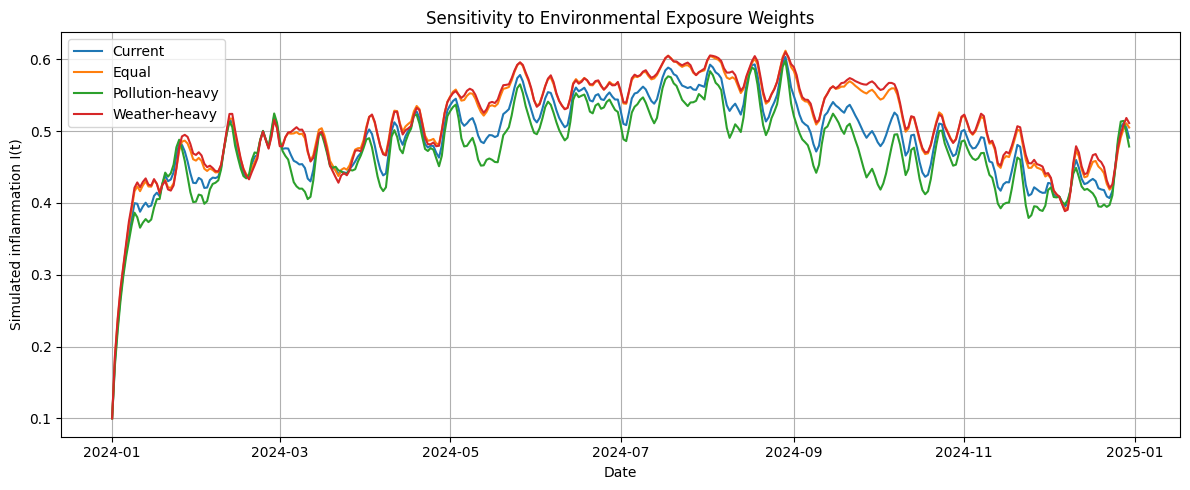

In [ ]:
plt.figure(figsize=(12, 5))

for name, curve in (
    weight_curves.items()
):

    plt.plot(
        dates,
        curve,
        label=name
    )

plt.xlabel("Date")

plt.ylabel(
    "Simulated inflammation I(t)"
)

plt.title(
    "Sensitivity to Environmental Exposure Weights"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "weight_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Mathematical Analysis

For constant environmental exposure $$E$$ and constant medication level $$M$$, the model becomes

$$
\frac{dI}{dt}
=
\alpha E(1-I)
-
(\beta M+\gamma)I.
$$

Expanding gives

$$
\frac{dI}{dt}
=
\alpha E
-
(\alpha E+\beta M+\gamma)I.
$$

### Equilibrium

At equilibrium,

$$
\frac{dI}{dt}=0.
$$

Therefore,

$$
0
=
\alpha E
-
(\alpha E+\beta M+\gamma)I^*,
$$

so

$$
I^*
=
\frac{\alpha E}
{\alpha E+\beta M+\gamma}.
$$

### Stability

Let

$$
f(I)
=
\alpha E
-
(\alpha E+\beta M+\gamma)I.
$$

Then

$$
\frac{df}{dI}
=
-(\alpha E+\beta M+\gamma).
$$

For nonnegative parameters with
$$\alpha E+\beta M+\gamma>0$$,

$$
\frac{df}{dI}<0.
$$

Therefore the unique equilibrium is globally exponentially stable under constant forcing.

### Boundedness

At $$I=0$$,

$$
\frac{dI}{dt}
=
\alpha E(t)\ge 0.
$$

At $$I=1$$,

$$
\frac{dI}{dt}
=
-(\beta M+\gamma)\le 0.
$$

Therefore the interval

$$
0\le I(t)\le1
$$

is forward invariant when the parameters and environmental exposure are nonnegative.

### Exact Constant-Exposure Solution

For constant $$E$$ and $$M$$, define

$$
k=\alpha E+\beta M+\gamma.
$$

Then

$$
I(t)
=
I^*
+
\left[I(0)-I^*\right]e^{-kt}.
$$

This exact solution will later be used to validate the numerical RK45 implementation.

## Structural Identifiability

The inflammation equation contains the medication and natural-recovery parameters through

$$
\beta M+\gamma.
$$

Because the baseline medication level $$M$$ is constant in this project, define

$$
\delta=\beta M+\gamma.
$$

The model can then be rewritten as

$$
\frac{dI}{dt}
=
\alpha E(t)(1-I)
-
\delta I.
$$

This means that different values of $$\beta$$ and $$\gamma$$ can produce exactly the same inflammation trajectory as long as they produce the same value of $$\delta$$.

Therefore, under constant medication, $$\beta$$ and $$\gamma$$ are **not separately structurally identifiable**. The combined parameter $$\delta$$ can be estimated instead.

In [ ]:
delta = (
    beta * medication_level
    + gamma
)

print(
    "Original combined delta:",
    delta
)


beta_alternative = 0.50

gamma_alternative = (
    delta
    - beta_alternative
    * medication_level
)

print(
    "Alternative beta:",
    beta_alternative
)

print(
    "Alternative gamma:",
    gamma_alternative
)

Original combined delta: 0.15000000000000002
Alternative beta: 0.5
Alternative gamma: 0.05000000000000002


In [ ]:
I_original_parameters = run_forward_model(
    exposure,
    beta_value=beta,
    gamma_value=gamma
)

I_alternative_parameters = run_forward_model(
    exposure,
    beta_value=beta_alternative,
    gamma_value=gamma_alternative
)

structural_difference = np.max(
    np.abs(
        I_original_parameters
        - I_alternative_parameters
    )
)

print(
    "Maximum difference between trajectories:",
    structural_difference
)

Maximum difference between trajectories: 0.0


## Reduced Identifiable Model

Because $$\beta$$ and $$\gamma$$ cannot be separately identified under constant medication, parameter estimation is performed using the reduced model

$$
\frac{dI}{dt}
=
\alpha E(t)(1-I)-\delta I.
$$

The parameters estimated in the inverse problem are therefore

$$
\alpha
\quad\text{and}\quad
\delta.
$$

In [ ]:
def run_alpha_delta_model(
    exposure_values,
    alpha_value,
    delta_value,
    initial_I=0.10
):

    exposure_values = np.asarray(
        exposure_values,
        dtype=float
    )

    n_days = len(
        exposure_values
    )

    local_t = np.arange(
        n_days
    )

    def exposure_function(t):

        return np.interp(
            t,
            local_t,
            exposure_values
        )

    def model(t, y):

        I = y[0]

        E = exposure_function(t)

        dI_dt = (
            alpha_value
            * E
            * (1 - I)
            - delta_value * I
        )

        return [dI_dt]

    solution = solve_ivp(
    model,
    (0, n_days - 1),
    [initial_I],
    t_eval=local_t,
    method="RK45",
    max_step=0.5,
    rtol=1e-6,
    atol=1e-8
)

    if not solution.success:

        raise RuntimeError(
            solution.message
        )

    return solution.y[0]


print(
    "Alpha-delta model defined."
)

Alpha-delta model defined.


## Synthetic Parameter-Recovery Test

No daily patient inflammation measurements are available for this project.

Therefore, the inverse-model procedure is tested using **synthetic observations** created from the model's known trajectory plus random noise.

This experiment tests whether the estimation algorithm can recover known parameters. It does **not** constitute clinical validation.

In [ ]:
true_alpha = alpha

true_delta = (
    beta * medication_level
    + gamma
)

rng_recovery = (
    np.random.default_rng(2026)
)

synthetic_observed_I = (
    real_inflammation
    +
    rng_recovery.normal(
        0,
        0.01,
        len(real_inflammation)
    )
)

synthetic_observed_I = np.clip(
    synthetic_observed_I,
    0,
    1
)

print(
    "True alpha:",
    true_alpha
)

print(
    "True delta:",
    true_delta
)

print(
    "Number of synthetic observations:",
    len(synthetic_observed_I)
)

True alpha: 0.35
True delta: 0.15000000000000002
Number of synthetic observations: 365


In [ ]:
def fit_alpha_delta(observed_I):

    def residuals(parameters):

        alpha_guess = parameters[0]
        delta_guess = parameters[1]

        predicted = run_alpha_delta_model(
            exposure,
            alpha_guess,
            delta_guess
        )

        return predicted - observed_I

    result = least_squares(
        residuals,

        x0=[
            0.25,
            0.20
        ],

        bounds=(
            [0.001, 0.001],
            [2.0, 2.0]
        ),

        max_nfev=200,

        diff_step=1e-5,

        ftol=1e-10,
        xtol=1e-10,
        gtol=1e-10
    )

    return result


print(
    "Parameter-fitting function defined."
)

Parameter-fitting function defined.


In [ ]:
fit_result = fit_alpha_delta(
    synthetic_observed_I
)

estimated_alpha = (
    fit_result.x[0]
)

estimated_delta = (
    fit_result.x[1]
)


alpha_percent_error = (
    100
    * abs(
        estimated_alpha
        - true_alpha
    )
    / true_alpha
)


delta_percent_error = (
    100
    * abs(
        estimated_delta
        - true_delta
    )
    / true_delta
)


print(
    "Fit successful:",
    fit_result.success
)

print(
    "True alpha:",
    true_alpha
)

print(
    "Estimated alpha:",
    estimated_alpha
)

print(
    "Alpha error (%):",
    alpha_percent_error
)

print()

print(
    "True delta:",
    true_delta
)

print(
    "Estimated delta:",
    estimated_delta
)

print(
    "Delta error (%):",
    delta_percent_error
)

Fit successful: True
True alpha: 0.35
Estimated alpha: 0.3220493171310596
Alpha error (%): 7.985909391125821

True delta: 0.15000000000000002
Estimated delta: 0.1376761618435922
Delta error (%): 8.215892104271887


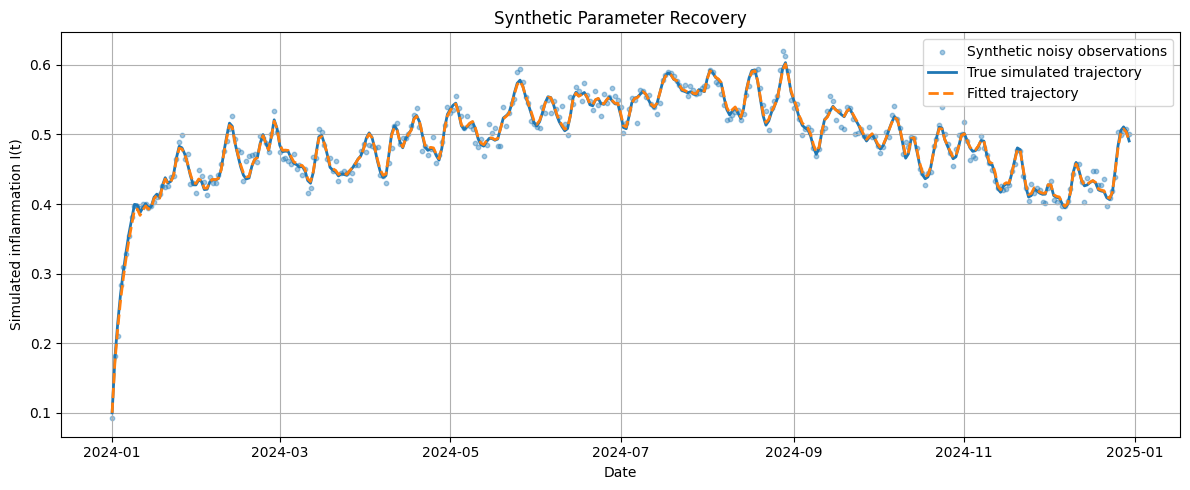

In [ ]:
fitted_inflammation = (
    run_alpha_delta_model(
        exposure,
        estimated_alpha,
        estimated_delta
    )
)


plt.figure(
    figsize=(12, 5)
)

plt.scatter(
    dates,
    synthetic_observed_I,
    s=10,
    alpha=0.4,
    label="Synthetic noisy observations"
)

plt.plot(
    dates,
    real_inflammation,
    linewidth=2,
    label="True simulated trajectory"
)

plt.plot(
    dates,
    fitted_inflammation,
    linestyle="--",
    linewidth=2,
    label="Fitted trajectory"
)

plt.xlabel("Date")

plt.ylabel(
    "Simulated inflammation I(t)"
)

plt.title(
    "Synthetic Parameter Recovery"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "parameter_recovery_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Practical Identifiability

Structural identifiability asks whether parameters can theoretically be distinguished.

Practical identifiability asks whether the available data contain enough information to distinguish them reliably in the presence of noise.

An error surface is calculated across candidate values of $$\alpha$$ and $$\delta$$. Lower mean-squared error indicates parameter combinations that fit the synthetic observations more closely.

In [ ]:
alpha_grid = np.linspace(
    0.20,
    0.50,
    11
)

delta_grid = np.linspace(
    0.08,
    0.22,
    11
)

error_surface = np.zeros(
    (
        len(delta_grid),
        len(alpha_grid)
    )
)

print(
    "Grid size:",
    error_surface.shape
)

print(
    "Total model runs:",
    len(alpha_grid)
    * len(delta_grid)
)

Grid size: (11, 11)
Total model runs: 121


In [ ]:
for i, delta_guess in enumerate(
    delta_grid
):

    print(
        f"Row {i + 1} "
        f"of {len(delta_grid)}"
    )

    for j, alpha_guess in enumerate(
        alpha_grid
    ):

        predicted = (
            run_alpha_delta_model(
                exposure,
                alpha_guess,
                delta_guess
            )
        )

        error_surface[
            i,
            j
        ] = np.mean(
            (
                predicted
                - synthetic_observed_I
            ) ** 2
        )

print(
    "Identifiability surface finished."
)

Row 1 of 11
Row 2 of 11
Row 3 of 11
Row 4 of 11
Row 5 of 11
Row 6 of 11
Row 7 of 11
Row 8 of 11
Row 9 of 11
Row 10 of 11
Row 11 of 11
Identifiability surface finished.


In [ ]:
minimum_index = (
    np.unravel_index(
        np.argmin(
            error_surface
        ),
        error_surface.shape
    )
)

best_delta_grid = (
    delta_grid[
        minimum_index[0]
    ]
)

best_alpha_grid = (
    alpha_grid[
        minimum_index[1]
    ]
)


print(
    "True alpha:",
    true_alpha
)

print(
    "Best grid alpha:",
    best_alpha_grid
)

print(
    "True delta:",
    true_delta
)

print(
    "Best grid delta:",
    best_delta_grid
)

True alpha: 0.35
Best grid alpha: 0.35
True delta: 0.15000000000000002
Best grid delta: 0.15000000000000002


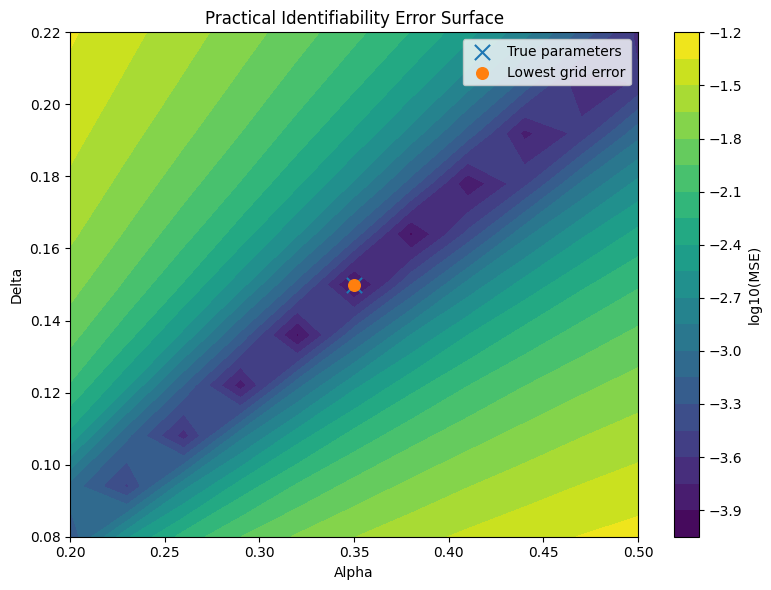

In [ ]:
plt.figure(
    figsize=(8, 6)
)

contour = plt.contourf(
    alpha_grid,
    delta_grid,
    np.log10(
        error_surface
        + 1e-12
    ),
    levels=25
)

plt.colorbar(
    contour,
    label="log10(MSE)"
)

plt.scatter(
    true_alpha,
    true_delta,
    marker="x",
    s=120,
    label="True parameters"
)

plt.scatter(
    best_alpha_grid,
    best_delta_grid,
    marker="o",
    s=70,
    label="Lowest grid error"
)

plt.xlabel(
    "Alpha"
)

plt.ylabel(
    "Delta"
)

plt.title(
    "Practical Identifiability Error Surface"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "identifiability_error_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Robustness of Parameter Recovery to Noise

The previous parameter-recovery experiment used one synthetic dataset with observational noise.

To test robustness, several synthetic datasets are generated at different noise levels. The parameters $$\alpha$$ and $$\delta$$ are estimated repeatedly.

This experiment asks whether parameter-estimation error tends to increase as observational noise becomes larger.

Because these observations are synthetically generated from the model itself, this tests the numerical inverse procedure rather than clinical validity.

In [ ]:
noise_levels = [
    0.00,
    0.01,
    0.05
]

trials_per_noise = 3

rng_noise = np.random.default_rng(
    100
)

noise_results = []


for sigma in noise_levels:

    print(
        "Testing noise level:",
        sigma
    )

    for trial in range(
        trials_per_noise
    ):

        noisy_I = (
            real_inflammation
            +
            rng_noise.normal(
                0,
                sigma,
                len(real_inflammation)
            )
        )

        noisy_I = np.clip(
            noisy_I,
            0,
            1
        )

        result = fit_alpha_delta(
            noisy_I
        )

        alpha_hat = (
            result.x[0]
        )

        delta_hat = (
            result.x[1]
        )

        alpha_error = (
            100
            * abs(
                alpha_hat
                - true_alpha
            )
            / true_alpha
        )

        delta_error = (
            100
            * abs(
                delta_hat
                - true_delta
            )
            / true_delta
        )

        noise_results.append({

            "Noise SD":
                sigma,

            "Trial":
                trial + 1,

            "Estimated alpha":
                alpha_hat,

            "Estimated delta":
                delta_hat,

            "Alpha percent error":
                alpha_error,

            "Delta percent error":
                delta_error
        })

        print(
            f"  Trial "
            f"{trial + 1}/"
            f"{trials_per_noise} finished"
        )


print(
    "Noise experiment finished."
)

Testing noise level: 0.0
  Trial 1/3 finished
  Trial 2/3 finished
  Trial 3/3 finished
Testing noise level: 0.01
  Trial 1/3 finished
  Trial 2/3 finished
  Trial 3/3 finished
Testing noise level: 0.05
  Trial 1/3 finished
  Trial 2/3 finished
  Trial 3/3 finished
Noise experiment finished.


In [ ]:
noise_results_df = pd.DataFrame(
    noise_results
)

display(
    noise_results_df
)


noise_summary = (
    noise_results_df
    .groupby("Noise SD")
    [
        [
            "Alpha percent error",
            "Delta percent error"
        ]
    ]
    .agg(
        ["mean", "std"]
    )
)

print(
    "Noise robustness summary:"
)

display(
    noise_summary
)

,Noise SD,Trial,Estimated alpha,Estimated delta,Alpha percent error,Delta percent error
0,0.00,1,0.355520,0.152380,1.577024,1.586593
1,0.00,2,0.355520,0.152380,1.577024,1.586593
2,0.00,3,0.355520,0.152380,1.577024,1.586593
3,0.01,1,0.347743,0.150986,0.644983,0.657575
4,0.01,2,0.348212,0.149688,0.510794,0.208057
5,0.01,3,0.328993,0.141126,6.001875,5.916075
6,0.05,1,0.311778,0.134135,10.920694,10.576522
7,0.05,2,0.324138,0.138790,7.389231,7.473102
8,0.05,3,0.318726,0.137373,8.935458,8.418254


Noise robustness summary:


Alpha percent error           Delta percent error          
                        mean       std                mean       std
Noise SD                                                            
0.00                1.577024  0.000000            1.586593  0.000000
0.01                2.385884  3.132259            2.260569  3.173730
0.05                9.081795  1.770274            8.822626  1.590737

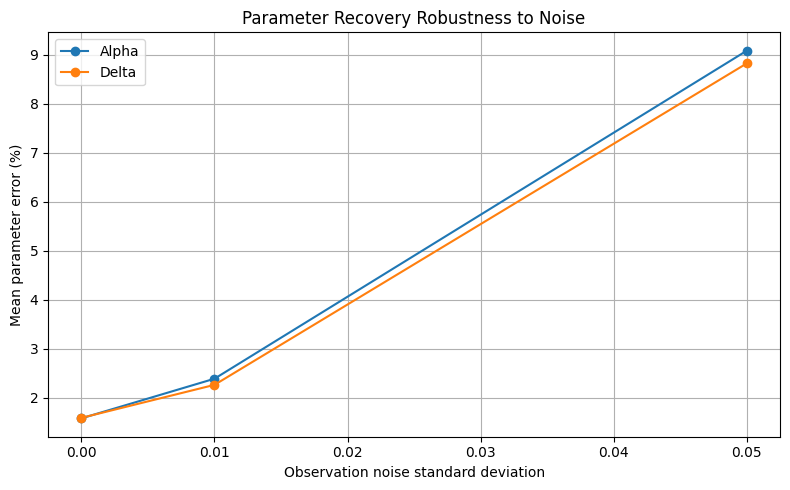

In [ ]:
noise_plot_data = (
    noise_results_df
    .groupby("Noise SD")
    [
        [
            "Alpha percent error",
            "Delta percent error"
        ]
    ]
    .mean()
    .reset_index()
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    noise_plot_data[
        "Noise SD"
    ],
    noise_plot_data[
        "Alpha percent error"
    ],
    marker="o",
    label="Alpha"
)

plt.plot(
    noise_plot_data[
        "Noise SD"
    ],
    noise_plot_data[
        "Delta percent error"
    ],
    marker="o",
    label="Delta"
)

plt.xlabel(
    "Observation noise standard deviation"
)

plt.ylabel(
    "Mean parameter error (%)"
)

plt.title(
    "Parameter Recovery Robustness to Noise"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "parameter_recovery_vs_noise.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Numerical Validation of RK45

For constant environmental exposure, the inflammation equation has an exact analytical solution.

This provides an independent way to test whether the numerical RK45 implementation is solving the differential equation accurately.

The exact solution and numerical solution are calculated under the same constant exposure and then directly compared.

In [ ]:
E_validation = 0.40

delta_validation = (
    beta * medication_level
    + gamma
)

k_validation = (
    alpha * E_validation
    + delta_validation
)

I_star_validation = (
    alpha * E_validation
    /
    k_validation
)


I_exact = (
    I_star_validation
    +
    (
        initial_inflammation
        - I_star_validation
    )
    *
    np.exp(
        -k_validation
        * t_data
    )
)


print(
    "Constant exposure:",
    E_validation
)

print(
    "Delta:",
    delta_validation
)

print(
    "Exact equilibrium:",
    I_star_validation
)

Constant exposure: 0.4
Delta: 0.15000000000000002
Exact equilibrium: 0.4827586206896551


In [ ]:
def constant_validation_model(
    t,
    y
):

    I = y[0]

    dI_dt = (
        alpha
        * E_validation
        * (1 - I)
        -
        delta_validation
        * I
    )

    return [dI_dt]


validation_solution = solve_ivp(
    constant_validation_model,
    (0, days - 1),
    [initial_inflammation],
    t_eval=t_data,
    method="RK45",
    max_step=0.5,
    rtol=1e-9,
    atol=1e-11
)


if not validation_solution.success:

    raise RuntimeError(
        validation_solution.message
    )


I_numerical = (
    validation_solution.y[0]
)

print(
    "Numerical validation solve finished."
)

Numerical validation solve finished.


In [ ]:
validation_max_error = (
    np.max(
        np.abs(
            I_exact
            - I_numerical
        )
    )
)


validation_rmse = (
    np.sqrt(
        np.mean(
            (
                I_exact
                - I_numerical
            ) ** 2
        )
    )
)


print(
    "Maximum absolute error:",
    validation_max_error
)

print(
    "RMSE:",
    validation_rmse
)

Maximum absolute error: 9.118333865743011e-11
RMSE: 1.3568223201224617e-11


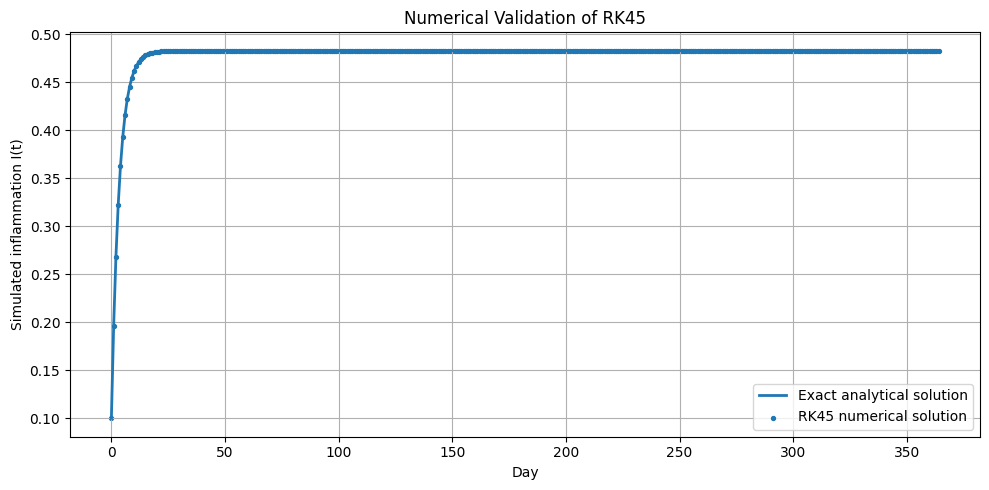

In [ ]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    t_data,
    I_exact,
    linewidth=2,
    label="Exact analytical solution"
)

plt.scatter(
    t_data,
    I_numerical,
    s=8,
    label="RK45 numerical solution"
)

plt.xlabel("Day")

plt.ylabel(
    "Simulated inflammation I(t)"
)

plt.title(
    "Numerical Validation of RK45"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "rk45_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Illustrative Risk Index

To provide a secondary summary of the simulated inflammation state, an illustrative logistic risk index is defined by

$$
R(t)
=
\frac{1}
{1+\exp[-(b_0+b_1I(t)+b_2A)]}.
$$

The coefficients in this transformation are assumed rather than clinically calibrated.

Therefore, $$R(t)$$ should be interpreted only as a **modeled risk index**, not as the probability that a patient will experience an asthma attack.

No clinical risk threshold is assigned.

Minimum modeled risk index: 0.10909682119561293
Maximum modeled risk index: 0.602446394118512
Mean modeled risk index: 0.46230146785285203


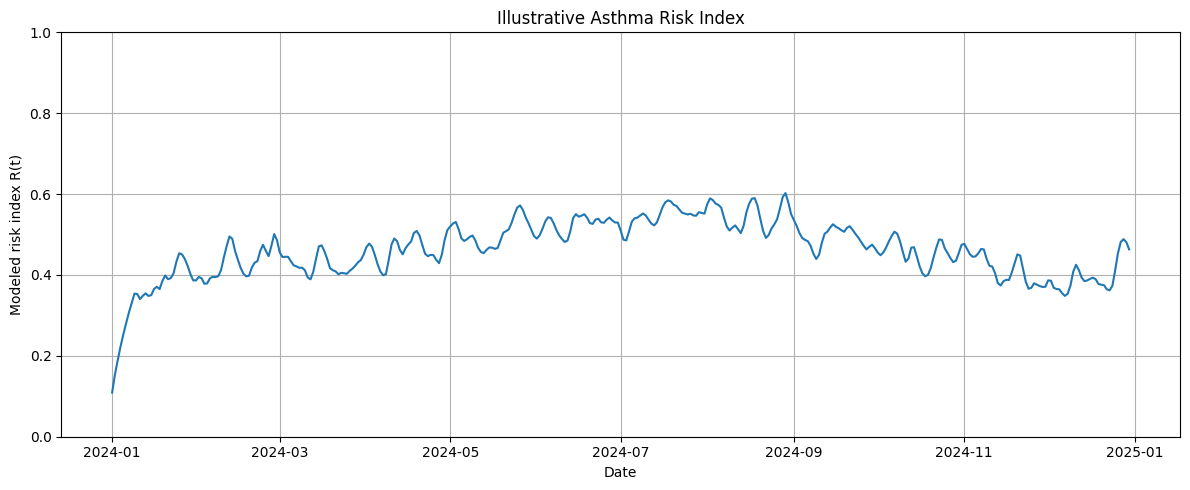

In [ ]:
real_risk_index = (
    1
    /
    (
        1
        +
        np.exp(
            -(
                b0
                + b1
                * real_inflammation
                + b2
                * baseline_vulnerability
            )
        )
    )
)


print(
    "Minimum modeled risk index:",
    np.min(
        real_risk_index
    )
)

print(
    "Maximum modeled risk index:",
    np.max(
        real_risk_index
    )
)

print(
    "Mean modeled risk index:",
    np.mean(
        real_risk_index
    )
)


plt.figure(
    figsize=(12, 5)
)

plt.plot(
    dates,
    real_risk_index
)

plt.xlabel("Date")

plt.ylabel(
    "Modeled risk index R(t)"
)

plt.title(
    "Illustrative Asthma Risk Index"
)

plt.ylim(
    0,
    1
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "illustrative_risk_index.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Limitations

This model is intended as a mathematical and computational framework rather than a clinically validated prediction system.

Important limitations include:

- The environmental exposure weights are assumed and have not been clinically calibrated.
- The parameters $$\alpha$$, $$\beta$$, and $$\gamma$$ are preliminary modeling assumptions.
- Simulated inflammation $$I(t)$$ is a latent mathematical state rather than a directly measured clinical biomarker.
- The risk index is illustrative and is not a calibrated probability of an asthma exacerbation.
- No individual-level asthma outcome data were available for clinical validation.
- Environmental monitoring stations represent regional outdoor conditions and may not equal an individual's personal exposure.
- Factors such as pollen, respiratory infection, indoor air quality, smoking exposure, physical activity, and medication adherence are not included.
- Temperature and humidity enter the exposure index linearly, although their real biological relationships with asthma may be more complicated.
- Min-max normalization is specific to the 2024 dataset, so exposure-index values are relative rather than universal.
- The model demonstrates mathematical responses to environmental forcing and should not be interpreted as establishing causation.

## Conclusions

This project developed a nonlinear ordinary differential equation model driven by real daily environmental measurements from 2024.

Controlled simulations showed that both the magnitude and duration of temporary environmental exposure events affected the peak and cumulative simulated inflammation response.

The timing experiment showed that the same added exposure event can produce different modeled responses depending on the background environmental conditions at the time of the event.

The model produced a strongest exposure-inflammation correlation at a short positive lag, demonstrating temporal smoothing and persistence rather than an instantaneous response.

Parameter-sensitivity testing showed that the simulated inflammation trajectory depends substantially on several assumed model parameters and environmental weighting choices.

Mathematical analysis showed that the inflammation state remains bounded between 0 and 1 and approaches a stable equilibrium under constant forcing.

Structural-identifiability analysis demonstrated that $$\beta$$ and $$\gamma$$ cannot be separately estimated under constant medication because the model depends on them only through the combined parameter

$$
\delta=\beta M+\gamma.
$$

Synthetic parameter-recovery experiments showed that the reduced parameters $$\alpha$$ and $$\delta$$ can be estimated from model-generated noisy observations, although practical identifiability analysis reveals correlation between the parameters.

Overall, the framework demonstrates how differential equations, environmental data, sensitivity analysis, and inverse modeling can be combined to study the temporal dynamics of simulated asthma-related inflammation.

In [ ]:
baseline_results.to_csv(
    "baseline_results.csv",
    index=False
)

scenario_table.to_csv(
    "scenario_results.csv",
    index=False
)

magnitude_table.to_csv(
    "magnitude_results.csv",
    index=False
)

duration_table.to_csv(
    "duration_results.csv",
    index=False
)

timing_table.to_csv(
    "timing_results.csv",
    index=False
)

lag_table.to_csv(
    "lag_results.csv",
    index=False
)

sensitivity_table.to_csv(
    "parameter_sensitivity.csv",
    index=False
)

weight_table.to_csv(
    "weight_sensitivity.csv",
    index=False
)

noise_results_df.to_csv(
    "noise_robustness_trials.csv",
    index=False
)


print(
    "Final tables exported."
)

Final tables exported.


In [ ]:
assert len(real_data) == 365

assert len(exposure) == days

assert len(real_inflammation) == days

assert np.all(
    np.isfinite(
        exposure
    )
)

assert np.all(
    np.isfinite(
        real_inflammation
    )
)

assert np.all(
    (
        real_inflammation >= 0
    )
    &
    (
        real_inflammation <= 1
    )
)

assert np.isclose(
    w_pm25
    + w_ozone
    + w_temperature
    + w_humidity,
    1.0
)

assert (
    structural_difference
    < 1e-10
)

assert (
    validation_max_error
    < 1e-5
)

assert fit_result.success


print(
    "ALL FINAL SANITY CHECKS PASSED."
)

ALL FINAL SANITY CHECKS PASSED.


In [ ]:
print(
    "=" * 65
)

print(
    "ASTHMA MODEL — FINAL SUMMARY"
)

print(
    "=" * 65
)


print(
    "\nEnvironmental observations:",
    days
)

print(
    "Mean environmental exposure:",
    np.mean(exposure)
)

print(
    "Mean simulated inflammation:",
    np.mean(
        real_inflammation
    )
)

print(
    "Maximum simulated inflammation:",
    np.max(
        real_inflammation
    )
)


print(
    "\nStrongest model-implied lag:",
    best_lag,
    "days"
)

print(
    "Lag correlation:",
    best_lag_correlation
)


print(
    "\nPARAMETER RECOVERY"
)

print(
    "Estimated alpha:",
    estimated_alpha
)

print(
    "Alpha error (%):",
    alpha_percent_error
)

print(
    "Estimated delta:",
    estimated_delta
)

print(
    "Delta error (%):",
    delta_percent_error
)


print(
    "\nSTRUCTURAL IDENTIFIABILITY"
)

print(
    "Equivalent beta/gamma "
    "trajectory difference:",
    structural_difference
)


print(
    "\nNUMERICAL VALIDATION"
)

print(
    "Maximum RK45 error:",
    validation_max_error
)

print(
    "RK45 RMSE:",
    validation_rmse
)


print(
    "\nFinished."
)

ASTHMA MODEL — FINAL SUMMARY

Environmental observations: 365
Mean environmental exposure: 0.4251856828657378
Mean simulated inflammation: 0.4886083300826838
Maximum simulated inflammation: 0.6031337812847415

Strongest model-implied lag: 2 days
Lag correlation: 0.780501754174577

PARAMETER RECOVERY
Estimated alpha: 0.3220493171310596
Alpha error (%): 7.985909391125821
Estimated delta: 0.1376761618435922
Delta error (%): 8.215892104271887

STRUCTURAL IDENTIFIABILITY
Equivalent beta/gamma trajectory difference: 0.0

NUMERICAL VALIDATION
Maximum RK45 error: 9.118333865743011e-11
RK45 RMSE: 1.3568223201224617e-11

Finished.


In [ ]:
zero_noise_fit = fit_alpha_delta(
    real_inflammation
)

zero_alpha = zero_noise_fit.x[0]
zero_delta = zero_noise_fit.x[1]

print(
    "Estimated alpha:",
    zero_alpha
)

print(
    "Alpha error (%):",
    100
    * abs(zero_alpha - true_alpha)
    / true_alpha
)

print(
    "Estimated delta:",
    zero_delta
)

print(
    "Delta error (%):",
    100
    * abs(zero_delta - true_delta)
    / true_delta
)

print(
    "Function evaluations:",
    zero_noise_fit.nfev
)

print(
    "Fit successful:",
    zero_noise_fit.success
)

Estimated alpha: 0.3555195856386202
Alpha error (%): 1.5770244681772017
Estimated delta: 0.1523798898908969
Delta error (%): 1.5865932605979198
Function evaluations: 22
Fit successful: True
